# L8 — Nhịp sử dụng: số ô tô đang sạc theo giờ, ngày, tuần

Notebook này dựng **năm loại biểu đồ** từ dữ liệu occupancy, theo đúng thứ tự bạn yêu cầu:

1. **Số ô tô đang sạc của một trạm** — 24 giờ / 7 ngày / 30 ngày *(đúng như ảnh mẫu)*
2. **Bảng nhiệt 7×24** của một trạm — toàn bộ nhịp tuần trong một cái nhìn
3. **Nhịp điển hình** (*typical*) — ngày điển hình và tuần điển hình, lấy mẫu từ 4 tuần
4. **So sánh nhịp giữa các nhóm** — Phường vs Xã, DC vs AC/MIXED
5. **Bản đồ dịch pha** — giờ cao điểm của từng nơi khác nhau thế nào

---

## Hai bảng dữ liệu, hai khái niệm khác nhau — đừng lẫn

| | `station_timeline` | `station_occupancy_profile_168h` |
|---|---|---|
| Ở đâu | `aGiang-evcs` *(nguồn, chỉ đọc)* | `evcs-hanoi/data/processed` |
| Là gì | **chuỗi thời gian thật**, kết thúc 29/07/2026 | **nhịp điển hình**, gộp từ cửa sổ 30 ngày |
| Trả lời | *"tối thứ Ba vừa rồi có mấy xe sạc?"* | *"tối thứ Ba **thường** có mấy xe?"* |
| Dùng cho | biểu đồ 1, 2 | biểu đồ 3, 4, 5 |

Cả hai đều cần. Chuỗi thật cho thấy **một tuần cụ thể** (có cả sự cố, ngày lễ, nhiễu);
nhịp điển hình cho thấy **quy luật** sau khi lấy trung bình 4 tuần.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
from vn import paths  # noqa: E402

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

st = pq.read_table(ROOT / "data/processed/stations.parquet").to_pandas()
occ = pq.read_table(ROOT / "data/processed/station_occupancy.parquet").to_pandas()
prof = pq.read_table(ROOT / "data/processed/station_occupancy_profile_168h.parquet").to_pandas()
grid = pq.read_table(ROOT / "data/processed/grid_h3_r8.parquet").to_pandas()
hn = st[st.scope == "HANOI"]

tl = pq.read_table(paths.AGIANG / "data/interim/occ/station_timeline.parquet").to_pandas()
tl = tl[tl.station_code.isin(set(hn.station_code))].set_index("station_code")

print(f"{len(hn):,} trạm Hà Nội (đã loại trạm 1 súng AC ở tầng nạp)")
print(f"{len(tl):,} trạm có chuỗi thời gian ({len(tl)/len(hn):.1%})")
print(f"{len(prof):,} dòng hồ sơ 168 giờ · {prof.station_code.nunique():,} trạm")

710 trạm Hà Nội (đã loại trạm 1 súng AC ở tầng nạp)
703 trạm có chuỗi thời gian (99.0%)
116,785 dòng hồ sơ 168 giờ · 703 trạm


## Đơn vị và bẫy — đọc trước khi vẽ

Từ `station_timeline.meta.json` của nguồn:

> **Đơn vị: `n_cars_charging` — SỐ XE NGUYÊN đang sạc.** Không phải phần trăm, không phải kWh.
>
> **Ô rỗng: `null` = không có thời lượng RESOLVED nào rơi vào ô. KHÔNG phải 0 xe.**

Ba cửa sổ, và **cách gộp khác nhau** — chỗ này rất dễ đọc nhầm:

| Cửa sổ | Số ô | Độ dài ô | Cách gộp |
|---|---|---|---|
| `m5` | 288 | 5 phút | **tức thời** (một ô = một quan sát) |
| `h168` | 168 | 1 giờ | **ĐỈNH** trong ô |
| `d30` | 30 | 1 ngày | **ĐỈNH** trong ô |

Nên đường "30 ngày" **không phải** trung bình mỗi ngày — nó là **đỉnh mỗi ngày**. Hai
đường sẽ khác nhau rất nhiều và không so trực tiếp được với nhau. Chú giải trên web phải
nói rõ, nếu không người xem sẽ tưởng trạm bận hơn thực tế khi kéo sang cửa sổ dài.

In [2]:
END_MS = 1785309300000  # mốc kết thúc, từ meta của nguồn
END = pd.Timestamp(END_MS, unit="ms", tz="Asia/Ho_Chi_Minh")
print("Chuỗi kết thúc:", END.strftime("%Y-%m-%d %H:%M %Z"))

WINDOWS = {
    "m5":   dict(n=288, freq="5min",  nhan="24 giờ", gop="tức thời"),
    "h168": dict(n=168, freq="1h",    nhan="7 ngày", gop="đỉnh mỗi giờ"),
    "d30":  dict(n=30,  freq="1D",    nhan="30 ngày", gop="đỉnh mỗi ngày"),
}


def series(code: str, win: str) -> pd.Series:
    """Chuỗi thời gian của một trạm, đã gắn nhãn thời gian thật."""
    w = WINDOWS[win]
    v = np.asarray(tl.loc[code, win], dtype=float)
    idx = pd.date_range(end=END, periods=w["n"], freq=w["freq"], tz="Asia/Ho_Chi_Minh")
    return pd.Series(v, index=idx)

Chuỗi kết thúc: 2026-07-29 14:15 +07


---
# Biểu đồ 1 — "SỐ Ô TÔ SẠC" của một trạm (24 giờ / 7 ngày / 30 ngày)

Đây là biểu đồ trong ảnh mẫu bạn gửi. Ta có đủ dữ liệu cho cả ba nút.

**Xử lý ô rỗng.** `null` nghĩa là *không quan sát được*, không phải *0 xe*. Vẽ nó thành 0
sẽ tạo ra những cú sụt giả xuống đáy. Cách xử lý:

- Khoảng trống **ngắn** (≤ 3 ô liên tiếp): nội suy tuyến tính — số xe đang sạc là đại
  lượng liên tục, một xe không biến mất rồi hiện lại trong 15 phút.
- Khoảng trống **dài**: **để trống**, đường đứt đoạn. Không bịa.

Cách này thoả điều kiện bạn nêu: chấp nhận được và **giải thích được**.

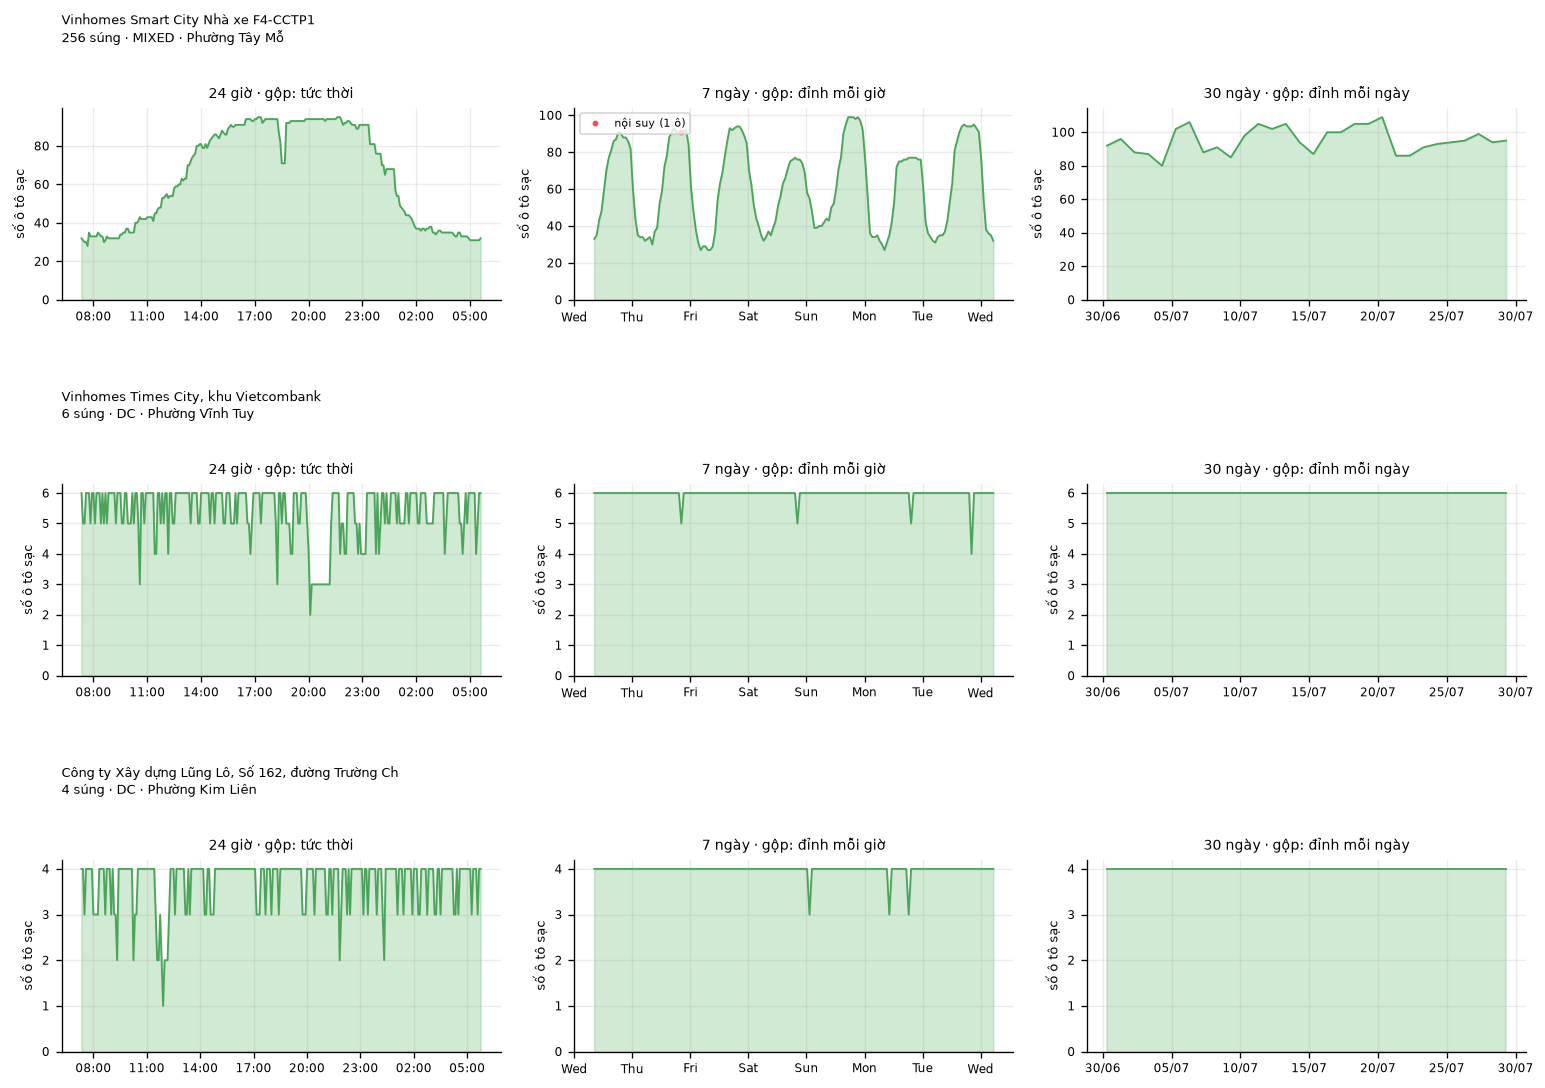

In [3]:
MAX_GAP = {"m5": 3, "h168": 2, "d30": 1}


def fill(s: pd.Series, win: str) -> tuple[pd.Series, pd.Series]:
    """Trả về (chuỗi đã vá, mặt nạ ô được nội suy). Khoảng trống dài giữ nguyên NaN."""
    lim = MAX_GAP[win]
    filled = s.interpolate(limit=lim, limit_area="inside")
    return filled, filled.notna() & s.isna()


def ve_tram(code: str, ax_row):
    info = hn[hn.station_code == code].iloc[0]
    for ax, win in zip(ax_row, WINDOWS):
        w = WINDOWS[win]
        raw = series(code, win)
        s, interp = fill(raw, win)
        ax.fill_between(s.index, 0, s.values, color="#7DC383", alpha=0.35)
        ax.plot(s.index, s.values, color="#4CA35C", lw=1.1)
        if interp.any():
            ax.plot(s.index[interp], s.values[interp], "o", ms=2.5,
                    color="#E45756", label=f"nội suy ({interp.sum()} ô)")
            ax.legend(fontsize=6.5, loc="upper left")
        ax.set_title(f"{w['nhan']} · gộp: {w['gop']}", fontsize=8.5)
        ax.set_ylim(bottom=0)
        ax.set_ylabel("số ô tô sạc", fontsize=8)
        if win == "m5":
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
        elif win == "h168":
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%a"))
            ax.xaxis.set_major_locator(mdates.DayLocator())
        else:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
            ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
        ax.tick_params(labelsize=7)
    ax_row[0].annotate(
        f"{info['name'][:52]}\n{int(info.n_ports)} súng · {info.current_type} · "
        f"{info.commune_name}",
        xy=(0, 1.32), xycoords="axes fraction", fontsize=8, va="bottom",
    )


cand = hn.merge(occ[["station_code", "grade", "util"]], on="station_code")
cand = cand[(cand.grade == "GOOD") & cand.station_code.isin(tl.index)]
picks = [
    cand.nlargest(1, "n_ports").station_code.iloc[0],
    cand[cand.n_ports.between(6, 15)].nlargest(1, "util").station_code.iloc[0],
    cand[(cand.current_type == "DC") & cand.n_ports.between(2, 6)].nlargest(1, "util").station_code.iloc[0],
]
fig, axes = plt.subplots(len(picks), 3, figsize=(13, 3.1 * len(picks)))
for r, code in enumerate(picks):
    ve_tram(code, axes[r])
plt.tight_layout(h_pad=3.0); plt.show()

**Đọc ba hàng này:**

- Cột **24 giờ** là dữ liệu thật ở độ phân giải 5 phút — thấy được từng xe cắm vào/rút ra.
  Đây là biểu đồ giống ảnh mẫu nhất.
- Cột **7 ngày** đã là *đỉnh mỗi giờ*, nên trần cao hơn cột 24 giờ. Nhìn thấy nhịp ngày rõ.
- Cột **30 ngày** là *đỉnh mỗi ngày* — mất hết chi tiết trong ngày, nhưng thấy được xu
  hướng và ngày bất thường.

Chấm đỏ là ô được nội suy. Chúng hiếm và ngắn, nên không bóp méo hình dạng — nhưng **hiển
thị chúng** để người xem biết chỗ nào là số đo, chỗ nào là suy ra.

---
# Biểu đồ 2 — Bảng nhiệt 7×24 của một trạm

Toàn bộ nhịp tuần trong một hình. Dùng `station_occupancy_profile_168h` (nhịp **điển
hình**, đã gộp 4 tuần) chứ không dùng chuỗi thật — vì ta muốn thấy **quy luật**, không
phải một tuần cụ thể.

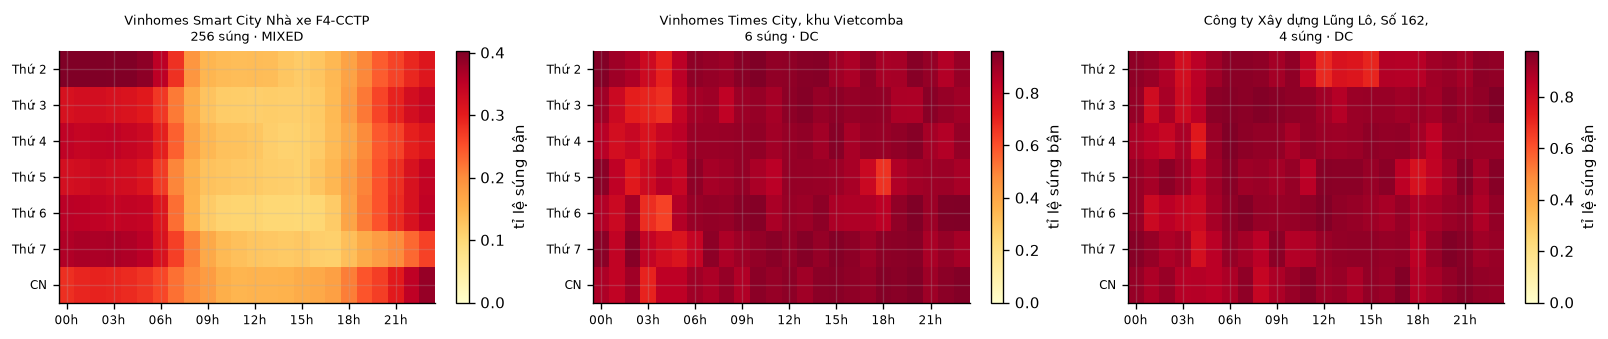

dấu × = ô có dưới 1 giờ quan sát → đọc dè dặt


In [4]:
DOW = ["Thứ 2", "Thứ 3", "Thứ 4", "Thứ 5", "Thứ 6", "Thứ 7", "CN"]
den = occ.set_index("station_code").util_denominator_ports


def heat(code: str, ax, gia_tri="ty_le"):
    p = prof[prof.station_code == code]
    M = np.full((7, 24), np.nan)
    O = np.full((7, 24), np.nan)
    d = float(den.get(code, np.nan))
    for _, r in p.iterrows():
        M[int(r.dow), int(r.hour)] = r.occ / d if gia_tri == "ty_le" else r.occ
        O[int(r.dow), int(r.hour)] = r.observed_h
    im = ax.imshow(M, aspect="auto", cmap="YlOrRd", vmin=0,
                   vmax=np.nanmax(M) if np.isfinite(M).any() else 1)
    # ô quan sát quá ít → gạch chéo, không tô đặc
    yy, xx = np.where(O < 1.0)
    ax.plot(xx, yy, "x", ms=3, color="#555", lw=0.5)
    ax.set_yticks(range(7)); ax.set_yticklabels(DOW, fontsize=7)
    ax.set_xticks(range(0, 24, 3)); ax.set_xticklabels([f"{h:02d}h" for h in range(0, 24, 3)], fontsize=7)
    return im


fig, axes = plt.subplots(1, 3, figsize=(13.5, 2.9))
for ax, code in zip(axes, picks):
    info = hn[hn.station_code == code].iloc[0]
    im = heat(code, ax)
    ax.set_title(f"{info['name'][:34]}\n{int(info.n_ports)} súng · {info.current_type}", fontsize=8)
    plt.colorbar(im, ax=ax, label="tỉ lệ súng bận", fraction=0.045)
plt.tight_layout(); plt.show()
print("dấu × = ô có dưới 1 giờ quan sát → đọc dè dặt")

---
# Biểu đồ 3 — Nhịp ĐIỂN HÌNH (*typical*)

Đây là thứ bạn nói tới: cửa sổ 30 ngày cho **4–5 mẫu cho mỗi ô (thứ, giờ)**, đủ để lấy
trung bình ra một tuần điển hình.

Bảng `station_occupancy_profile_168h` **đã làm sẵn việc này**. Kiểm chứng bằng `n_obs`.

In [5]:
print("Số mẫu mỗi ô (thứ, giờ) — n_obs:")
print(prof.n_obs.describe().round(2).to_string())
print(f"\nÔ có ≥ 4 mẫu: {(prof.n_obs >= 4).mean():.1%}")
print(f"Ô có ≥ 3 mẫu: {(prof.n_obs >= 3).mean():.1%}")
print(f"observed_h trung vị: {prof.observed_h.median():.2f} giờ / ô")

Số mẫu mỗi ô (thứ, giờ) — n_obs:
count    116785.00
mean         30.76
std          15.22
min           0.00
25%          19.00
50%          32.00
75%          43.00
max          60.00

Ô có ≥ 4 mẫu: 96.2%
Ô có ≥ 3 mẫu: 97.4%
observed_h trung vị: 4.00 giờ / ô


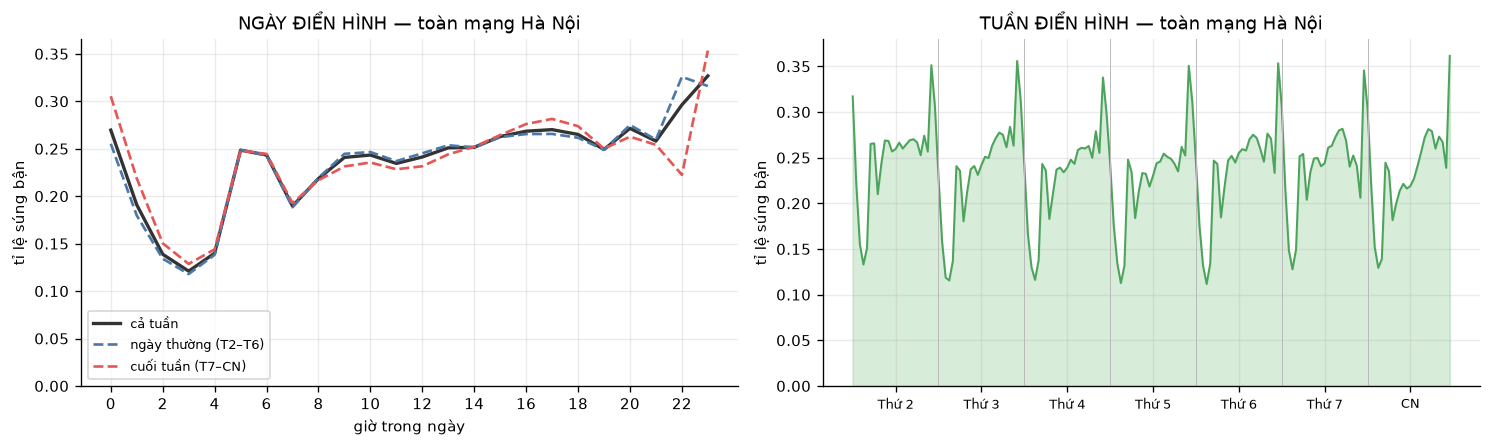

Đỉnh : CN 23h — 36.2% súng bận
Đáy  : Thứ 6 03h — 11.2%
Biên độ đỉnh/đáy: 3.24×   ·   trung bình tuần: 23.7%


In [6]:
p = prof.merge(hn[["station_code", "n_ports", "current_type", "h3_r8", "commune_name"]],
               on="station_code", how="inner")
p["den"] = p.station_code.map(den)
p = p[(p.den > 0) & p.observed_h.notna()]
p["ty_le"] = (p.occ / p.den).clip(upper=1.0)

# tuần điển hình toàn mạng, có trọng số theo số cổng
tuan = p.groupby(["dow", "hour"]).apply(
    lambda x: pd.Series({"ty_le": np.average(x.ty_le, weights=x.den),
                         "xe": np.sum(x.occ),
                         "obs": x.observed_h.median()}), include_groups=False).reset_index()
ngay = p.groupby("hour").apply(
    lambda x: pd.Series({"ty_le": np.average(x.ty_le, weights=x.den)}), include_groups=False)
ngay_thuong = p[p.dow < 5].groupby("hour").apply(
    lambda x: pd.Series({"ty_le": np.average(x.ty_le, weights=x.den)}), include_groups=False)
cuoi_tuan = p[p.dow >= 5].groupby("hour").apply(
    lambda x: pd.Series({"ty_le": np.average(x.ty_le, weights=x.den)}), include_groups=False)

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].plot(ngay.index, ngay.ty_le, color="#333", lw=2, label="cả tuần")
ax[0].plot(ngay_thuong.index, ngay_thuong.ty_le, color="#4C78A8", lw=1.6, ls="--", label="ngày thường (T2–T6)")
ax[0].plot(cuoi_tuan.index, cuoi_tuan.ty_le, color="#E45756", lw=1.6, ls="--", label="cuối tuần (T7–CN)")
ax[0].set_xlabel("giờ trong ngày"); ax[0].set_ylabel("tỉ lệ súng bận")
ax[0].set_title("NGÀY ĐIỂN HÌNH — toàn mạng Hà Nội")
ax[0].set_xticks(range(0, 24, 2)); ax[0].legend(fontsize=8); ax[0].set_ylim(bottom=0)

x = np.arange(168)
ax[1].plot(x, tuan.sort_values(["dow", "hour"]).ty_le.values, color="#4CA35C", lw=1.2)
ax[1].fill_between(x, 0, tuan.sort_values(["dow", "hour"]).ty_le.values, color="#7DC383", alpha=0.3)
for d_ in range(1, 7):
    ax[1].axvline(d_ * 24, color="#bbb", lw=0.6)
ax[1].set_xticks([d_ * 24 + 12 for d_ in range(7)]); ax[1].set_xticklabels(DOW, fontsize=8)
ax[1].set_ylabel("tỉ lệ súng bận"); ax[1].set_title("TUẦN ĐIỂN HÌNH — toàn mạng Hà Nội")
ax[1].set_ylim(bottom=0)
plt.tight_layout(); plt.show()

pk = tuan.loc[tuan.ty_le.idxmax()]
tr = tuan.loc[tuan.ty_le.idxmin()]
print(f"Đỉnh : {DOW[int(pk.dow)]} {int(pk.hour):02d}h — {pk.ty_le:.1%} súng bận")
print(f"Đáy  : {DOW[int(tr.dow)]} {int(tr.hour):02d}h — {tr.ty_le:.1%}")
print(f"Biên độ đỉnh/đáy: {pk.ty_le/tr.ty_le:.2f}×   ·   trung bình tuần: {tuan.ty_le.mean():.1%}")

---
# Biểu đồ 4 — So sánh nhịp giữa các nhóm

Đây là chỗ nhịp trở thành **insight** chứ không chỉ là hình đẹp: các nhóm khác nhau có
nhu cầu ở **thời điểm khác nhau**, và điều đó quyết định **loại trạm nên đặt**.

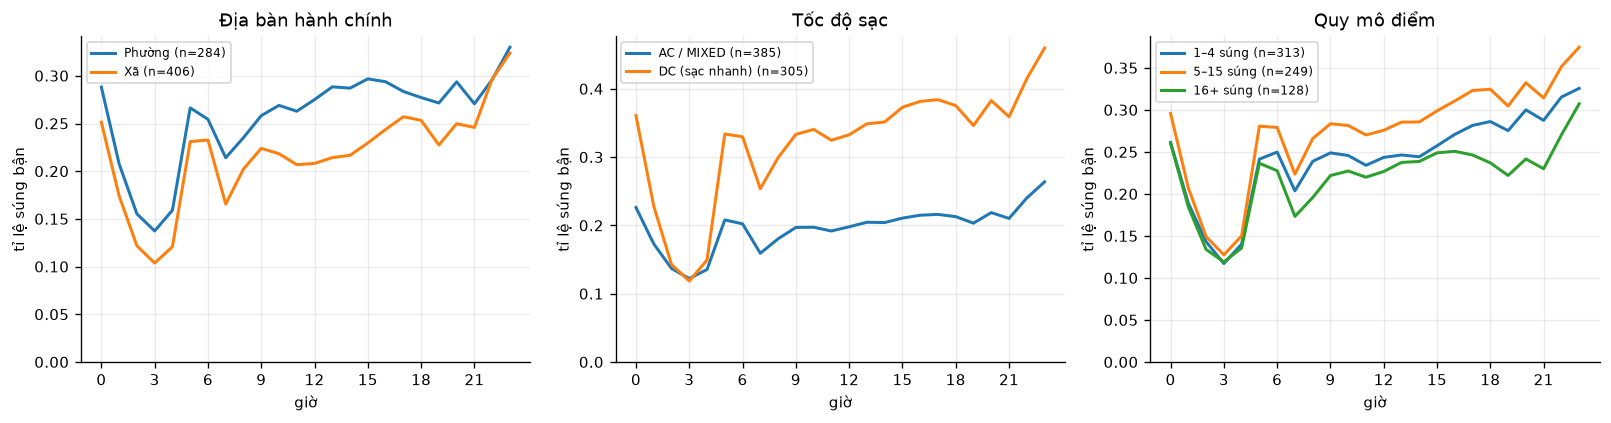

In [7]:
p["loai_xa"] = np.where(p.commune_name.str.startswith("Phường"), "Phường", "Xã")
p["toc_do"] = np.where(p.current_type == "DC", "DC (sạc nhanh)", "AC / MIXED")
p["quy_mo"] = pd.cut(p.n_ports, [0, 4, 15, 1000], labels=["1–4 súng", "5–15 súng", "16+ súng"])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.6))
for ax, col, title in zip(axes, ["loai_xa", "toc_do", "quy_mo"],
                          ["Địa bàn hành chính", "Tốc độ sạc", "Quy mô điểm"]):
    for k, sub in p.groupby(col, observed=True):
        h = sub.groupby("hour").apply(
            lambda x: np.average(x.ty_le, weights=x.den), include_groups=False)
        ax.plot(h.index, h.values, lw=1.8, label=f"{k} (n={sub.station_code.nunique()})")
    ax.set_xlabel("giờ"); ax.set_ylabel("tỉ lệ súng bận"); ax.set_title(title)
    ax.set_xticks(range(0, 24, 3)); ax.legend(fontsize=7); ax.set_ylim(bottom=0)
plt.tight_layout(); plt.show()

In [8]:
print("Giờ cao điểm của từng nhóm (ngày điển hình):\n")
rows = []
for col in ["loai_xa", "toc_do", "quy_mo"]:
    for k, sub in p.groupby(col, observed=True):
        h = sub.groupby("hour").apply(
            lambda x: np.average(x.ty_le, weights=x.den), include_groups=False)
        rows.append({"nhóm": str(k), "giờ đỉnh": int(h.idxmax()), "tỉ lệ đỉnh": h.max(),
                     "tỉ lệ đáy": h.min(), "biên độ": h.max() / h.min(),
                     "n trạm": sub.station_code.nunique()})
display(pd.DataFrame(rows).set_index("nhóm").round(3))

Giờ cao điểm của từng nhóm (ngày điển hình):



,giờ đỉnh,tỉ lệ đỉnh,tỉ lệ đáy,biên độ,n trạm
nhóm,,,,,
Phường,23,0.330,0.137,2.402,284
Xã,23,0.324,0.104,3.121,406
AC / MIXED,23,0.264,0.122,2.158,385
DC (sạc nhanh),23,0.460,0.119,3.876,305
1–4 súng,23,0.326,0.117,2.777,313
5–15 súng,23,0.375,0.128,2.938,249
16+ súng,23,0.307,0.119,2.579,128


**Biên độ** là cột đáng chú ý nhất, vì nó nói loại hạ tầng nào phù hợp:

- **Biên độ cao** = nhu cầu dồn vào vài giờ → cần **sạc nhanh DC** (quay vòng nhanh trong
  giờ cao điểm), hoặc phải chấp nhận trần công suất cao mà phần lớn thời gian nhàn rỗi.
- **Biên độ thấp** = nhu cầu trải đều → **sạc chậm AC nhiều trụ** hiệu quả hơn về vốn.

Đây là kết luận mà không trường tĩnh nào (`util`, `n_ports`, `power_kw_site`) cho được —
nó chỉ tồn tại ở chiều thời gian.

---
# Biểu đồ 5 — Bản đồ dịch pha: giờ cao điểm khác nhau ở đâu

Mỗi ô lưới có một **giờ đỉnh**. Tô bản đồ theo giờ đỉnh (thang màu tuần hoàn) sẽ cho thấy
nhu cầu **di chuyển trong ngày** như thế nào trên không gian.

437/4,400 ô có nhịp đo được (10%) — phần còn lại KHÔNG có trạm đo được, phải để trống chứ không tô 0


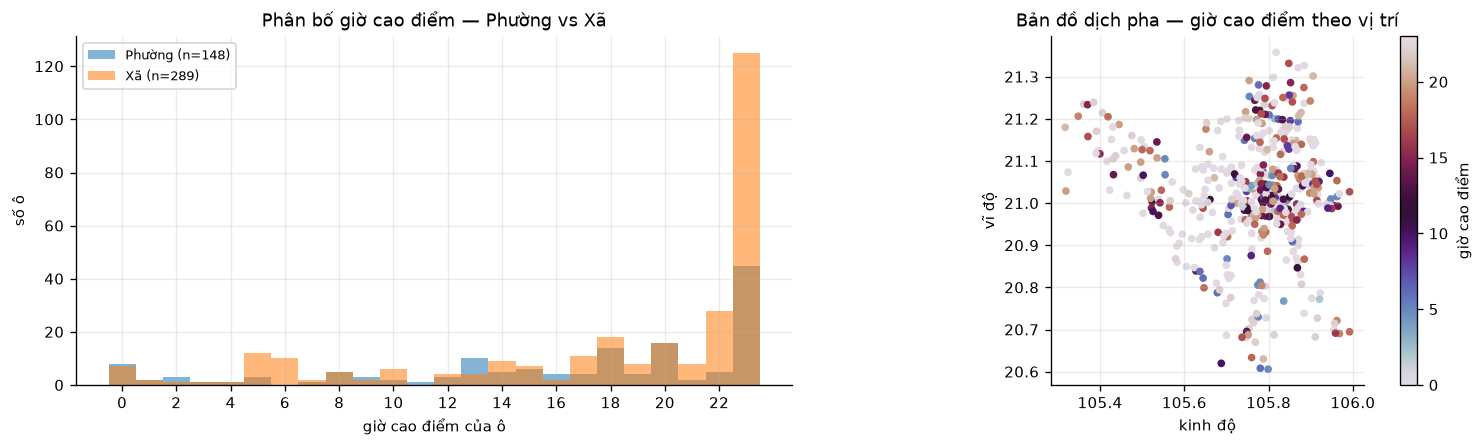


Giờ đỉnh trung vị — Phường: 18h · Xã: 22h
Biên độ trung vị — Phường: 4.37× · Xã: 6.68×


In [9]:
cell = p.groupby(["h3_r8", "hour"]).apply(
    lambda x: np.average(x.ty_le, weights=x.den), include_groups=False).rename("ty_le").reset_index()
peak_cell = cell.loc[cell.groupby("h3_r8").ty_le.idxmax()][["h3_r8", "hour", "ty_le"]]
peak_cell = peak_cell.rename(columns={"hour": "gio_dinh", "ty_le": "dinh"})
amp = cell.groupby("h3_r8").ty_le.agg(["max", "min"])
peak_cell["bien_do"] = peak_cell.h3_r8.map(amp["max"] / amp["min"].replace(0, np.nan))

G = grid.merge(peak_cell, on="h3_r8", how="left")
G["loai_xa"] = np.where(G.commune_name.str.startswith("Phường"), "Phường", "Xã")
have = G[G.gio_dinh.notna()]
print(f"{len(have):,}/{len(G):,} ô có nhịp đo được ({len(have)/len(G):.0%}) — "
      f"phần còn lại KHÔNG có trạm đo được, phải để trống chứ không tô 0")

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
for k, sub in have.groupby("loai_xa"):
    ax[0].hist(sub.gio_dinh, bins=np.arange(25) - 0.5, alpha=0.55, label=f"{k} (n={len(sub)})")
ax[0].set_xlabel("giờ cao điểm của ô"); ax[0].set_ylabel("số ô")
ax[0].set_title("Phân bố giờ cao điểm — Phường vs Xã")
ax[0].set_xticks(range(0, 24, 2)); ax[0].legend(fontsize=8)

sc = ax[1].scatter(have.lng, have.lat, c=have.gio_dinh, s=13, cmap="twilight", vmin=0, vmax=23)
ax[1].set_title("Bản đồ dịch pha — giờ cao điểm theo vị trí")
ax[1].set_xlabel("kinh độ"); ax[1].set_ylabel("vĩ độ"); ax[1].set_aspect("equal")
plt.colorbar(sc, ax=ax[1], label="giờ cao điểm", fraction=0.04)
plt.tight_layout(); plt.show()

print(f"\nGiờ đỉnh trung vị — Phường: {have[have.loai_xa=='Phường'].gio_dinh.median():.0f}h · "
      f"Xã: {have[have.loai_xa=='Xã'].gio_dinh.median():.0f}h")
print(f"Biên độ trung vị — Phường: {have[have.loai_xa=='Phường'].bien_do.median():.2f}× · "
      f"Xã: {have[have.loai_xa=='Xã'].bien_do.median():.2f}×")

---
# Cần thêm gì ở tầng pipeline

Bốn trong năm biểu đồ chạy được ngay trên `data/processed`. Riêng **biểu đồ 1** đọc
`station_timeline.parquet` từ repo nguồn (chỉ đọc), nên bộ dữ liệu **chưa đứng độc lập**
cho lớp này.

Đề nghị thêm vào `s06_occupancy.py`: xuất `station_timeline_hanoi.parquet` — cắt về trạm
Hà Nội sau lọc, giữ nguyên ba cửa sổ `m5`/`h168`/`d30`, kèm mốc `end_ms` trong QA. Kích
thước ước tính < 1 MB cho 703 trạm.

## Tóm tắt: năm biểu đồ và câu hỏi mỗi cái trả lời

| # | Biểu đồ | Câu hỏi | Nguồn |
|---|---|---|---|
| 1 | Số ô tô sạc 24h/7d/30d | *"Trạm này hôm qua thế nào?"* | `station_timeline` |
| 2 | Bảng nhiệt 7×24 | *"Nhịp tuần của trạm này ra sao?"* | `profile_168h` |
| 3 | Ngày/tuần điển hình | *"Toàn mạng bận lúc nào?"* | `profile_168h` |
| 4 | So nhóm | *"Nhóm nào cần loại trạm nào?"* | `profile_168h` |
| 5 | Bản đồ dịch pha | *"Nhu cầu dịch chuyển thế nào trong ngày?"* | `profile_168h` |

---
---
# §6 — Phản biện: *"cảm giác mọi lúc đều giống nhau"*

Bạn nhìn năm biểu đồ trên và nói chúng na ná nhau, nghi cách gộp có vấn đề. Tôi đã dựng lại
**từ dữ liệu thô** (`load_ts_2026-07-29-full.csv`, 38,3 triệu dòng, 3,62 triệu dòng thuộc
Hà Nội) thay vì tin bảng đã gộp sẵn. Script: `analysis/a18_l8_gop_nhip.py`.

Tôi vào cuộc với ba nghi ngờ. **Hai cái sai, một cái đúng — và cái đúng không nằm trong ba
cái đó.**

| # | Nghi ngờ ban đầu | Kết quả đo |
|---|---|---|
| a | Gộp bằng **ĐỈNH** làm mọi đường chạm trần | ✗ chỉ **12,2%** ô giờ chạm trần |
| b | Trục giờ bị lệch **UTC vs giờ VN** | ✗ đúng giờ địa phương UTC+7 |
| c | Vài **trạm lớn** nuốt đường tổng hợp | ✗ trạm lớn/nhỏ cùng hình dạng |
| **d** | *(không nghĩ tới)* **Lệch pha triệt tiêu biên độ khi gộp** | ✓ **mất 66,8% biên độ** |

Và một lỗi của chính tôi phải nói ra: lần đo đầu tôi đọc nhầm `load_ts.csv` — một lượt
crawl **cũ, ngắn hơn 8,5 ngày**. Nó cho "giờ đỉnh 23h" và "tháng chỉ phủ 23%". Cả hai đều
sai. File đúng là `timeseries_runs/load_ts_2026-07-29-full.csv`, đủ **30,0 ngày**.

In [10]:
import json

AUD = ROOT / "data/qa/critique"
A = json.load(open(AUD / "a18_l8.json", encoding="utf-8"))
curves = pq.read_table(AUD / "l8_duong_cong_168.parquet").to_pandas()
H = np.load(AUD / "l8_h168_dinh.npy")          # (trạm, 168) gộp ĐỈNH
Hm = np.load(AUD / "l8_h168_tb.npy")           # (trạm, 168) gộp TRUNG BÌNH có trọng số
W15 = np.load(AUD / "l8_tuan_15p_dinh.npy")    # (trạm, 672) tuần ở lưới 15 phút
sidx = pq.read_table(AUD / "l8_station_index.parquet").to_pandas().station_code.tolist()

for k in A["ket_luan"]:
    print("•", k)

• Cửa sổ thật: 30.0 ngày (31 ngày lịch có dữ liệu).
• Nhịp lấy mẫu thật: trung vị 5.0 phút, p90 15.0 phút — 75.4% số khoảng ≤ 5 phút.
• Múi giờ: giờ ĐỊA PHƯƠNG (UTC+7).
• Gộp ĐỈNH cho giá trị lớn hơn trung bình 1.27× ở ô giờ; CV đường tổng hợp đỉnh 0.205 vs trung bình 0.216.
• Giờ đỉnh: không trọng số 9h · trọng số cổng 9h · trạm lớn 9h · trạm nhỏ 9h.
• Biên độ: từng trạm CV trung vị 0.619, đường đã gộp CV 0.205 — mất 66.8% biên độ khi gộp; đỉnh của từng trạm rải ra 24 giờ khác nhau.
• Bão hoà MAX: 12.2% số ô giờ chạm đúng trần của trạm; tản mạn giờ đỉnh MAX 0.644 vs TRUNG BÌNH 0.648.


## 6.1 — Dữ liệu thô dày hơn tôi tưởng, và cửa sổ đúng là 30 ngày

Nhịp lấy mẫu là **lưới 5 phút thật sự**: p25 = p50 = p75 = 5,0 phút. Không phải "poll ngẫu
nhiên rồi nội suy" — nguồn ghi đều đặn, có rớt nhịp (p90 = 15 phút, p99 = 50 phút).

Nghĩa là **mọi độ phân giải bạn yêu cầu đều dựng được từ số liệu thật**, không phải bịa ra
bằng nội suy. Nhưng phải đọc độ phủ **theo từng trạm**, không phải gộp mọi trạm — gộp lại
thì ô nào cũng có ai đó báo số, luôn ra ~100% và con số đó vô nghĩa.

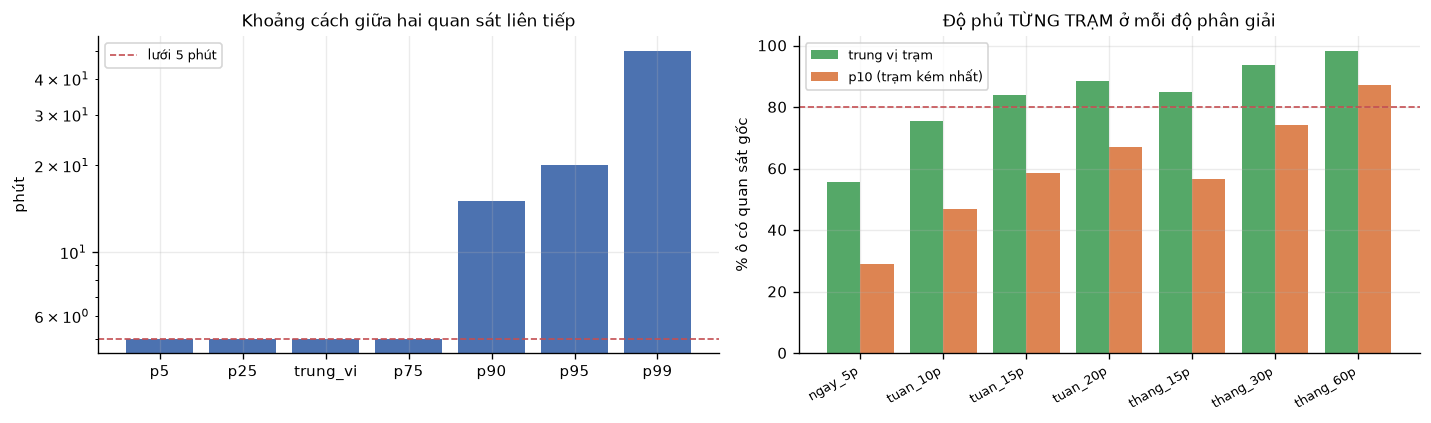

Cửa sổ: 2026-06-29 → 2026-07-29 = 30.0 ngày


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))

ph = A["1_nhip_lay_mau"]["khoang_cach_quan_sat_phut"]
ks = list(ph.keys())
ax[0].bar(ks, [ph[k] for k in ks], color="#4C72B0")
ax[0].axhline(5, color="#C44E52", ls="--", lw=1, label="lưới 5 phút")
ax[0].set_yscale("log"); ax[0].set_ylabel("phút"); ax[0].legend(fontsize=8)
ax[0].set_title("Khoảng cách giữa hai quan sát liên tiếp", fontsize=10)

pv = A["2_do_phu_theo_do_phan_giai"]
names = list(pv.keys())
med = [pv[k]["tung_tram__share_o_trung_vi"] * 100 for k in names]
p10 = [pv[k]["tung_tram__share_o_p10"] * 100 for k in names]
x = np.arange(len(names))
ax[1].bar(x - 0.2, med, 0.4, label="trung vị trạm", color="#55A868")
ax[1].bar(x + 0.2, p10, 0.4, label="p10 (trạm kém nhất)", color="#DD8452")
ax[1].axhline(80, color="#C44E52", ls="--", lw=1)
ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=30, ha="right", fontsize=8)
ax[1].set_ylabel("% ô có quan sát gốc"); ax[1].legend(fontsize=8)
ax[1].set_title("Độ phủ TỪNG TRẠM ở mỗi độ phân giải", fontsize=10)
plt.tight_layout(); plt.show()

print("Cửa sổ:", A["1_nhip_lay_mau"]["bat_dau_utc"][:10], "→",
      A["1_nhip_lay_mau"]["ket_thuc_utc"][:10],
      f"= {A['1_nhip_lay_mau']['do_dai_cua_so_ngay']:.1f} ngày")

**Đọc bảng bên phải như sau.** Đường đỏ là mốc 80% — dưới mốc đó thì đường vẽ ra sẽ đứt
quãng nhiều hơn liền.

| Bạn yêu cầu | Trung vị trạm | Kết luận |
|---|---|---|
| ngày **5′** | 55,6% | ⚠️ mỏng — 273/703 trạm phủ dưới 50% |
| tuần **10′** | 75,5% | ⚠️ ngấp nghé |
| tuần **15′** | 83,8% | ✅ dùng được |
| tuần **20′** | 88,5% | ✅ an toàn |
| tháng **15′** | 84,8% | ✅ dùng được |
| tháng **30′** | 93,8% | ✅ tốt |
| tháng **60′** | 98,1% | ✅ gần như đầy |

Nghịch lý biểu kiến — *tháng 15′ (84,8%) phủ tốt hơn ngày 5′ (55,6%)* — không phải lỗi:
ô 15 phút rộng gấp ba ô 5 phút nên dễ "bắt" được ít nhất một quan sát hơn, và cửa sổ 30
ngày gồm cả những ngày trạm báo số đều, trong khi cửa sổ 24 giờ cuối có thể rơi trúng đoạn
rớt nhịp.

**Khuyến nghị:** ngày **5′** (giữ, đúng lưới nguồn) · tuần **15′** · tháng **30′**.
Muốn mịn hơn thì phải phát kèm cột độ phủ để người xem biết chỗ nào là số liệu, chỗ nào là
khoảng trống được nối.

## 6.2 — Thủ phạm thật: gộp làm **mất 2/3 biên độ**

Đây là câu trả lời cho câu hỏi của bạn.

Từng trạm **có nhịp rất rõ** — hệ số biến thiên (độ "gợn sóng" của đường cong, tính bằng
độ lệch chuẩn chia trung bình) trung vị là **0,62**. Nhưng đường tổng hợp chỉ còn **0,21**.

Biên độ không bị phép gộp trong ô làm mất. Nó bị mất khi **cộng 703 trạm lệch pha nhau lại**:
trạm này đỉnh lúc 9h, trạm kia đỉnh lúc 2h, cộng vào nhau thì đỉnh nọ lấp đáy kia.

/tmp/ipykernel_919590/2789456045.py:2: RuntimeWarning: invalid value encountered in divide
  cv_tram = np.nanstd(H[du], 1) / np.nanmean(H[du], 1)
/tmp/ipykernel_919590/2789456045.py:16: RuntimeWarning: invalid value encountered in divide
  Mn = M / np.nanmean(M, 1, keepdims=True)


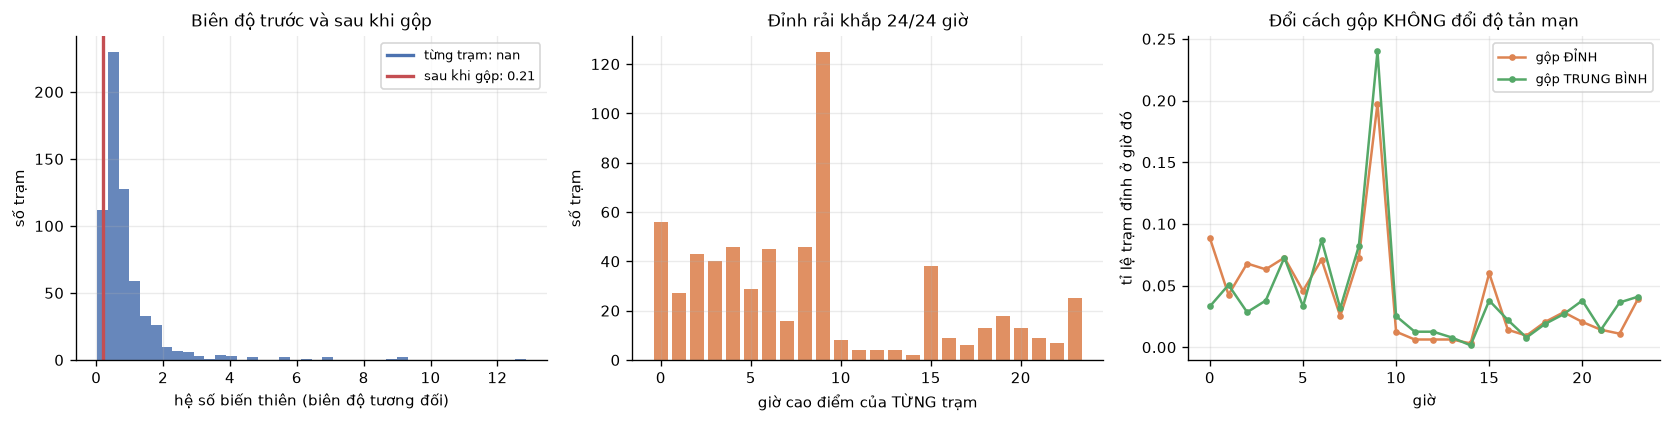

tản mạn giờ đỉnh — gộp ĐỈNH 0.644 · gộp TRUNG BÌNH 0.648   (0 = cùng pha, 1 = rải đều)
ô giờ chạm đúng trần của trạm: 12.2% → MAX KHÔNG bị bão hoà


In [12]:
du = np.isfinite(H).sum(1) >= 120
cv_tram = np.nanstd(H[du], 1) / np.nanmean(H[du], 1)
hh = np.arange(168) % 24

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))

ax[0].hist(cv_tram, bins=40, color="#4C72B0", alpha=.85)
ax[0].axvline(np.median(cv_tram), color="#4C72B0", lw=2, label=f"từng trạm: {np.median(cv_tram):.2f}")
ax[0].axvline(A["6_gop_triet_tieu_nhip"]["CV_duong_da_gop_tho"], color="#C44E52", lw=2,
              label=f"sau khi gộp: {A['6_gop_triet_tieu_nhip']['CV_duong_da_gop_tho']:.2f}")
ax[0].set_xlabel("hệ số biến thiên (biên độ tương đối)"); ax[0].set_ylabel("số trạm")
ax[0].legend(fontsize=8); ax[0].set_title("Biên độ trước và sau khi gộp", fontsize=10)

def dinh_theo_tram(M):
    out = []
    Mn = M / np.nanmean(M, 1, keepdims=True)
    for i in np.flatnonzero(du):
        s = pd.Series(Mn[i]).groupby(hh).mean()
        if s.notna().any():
            out.append(int(s.idxmax()))
    return np.asarray(out)

d_max, d_tb = dinh_theo_tram(H), dinh_theo_tram(Hm)
ax[1].bar(*np.unique(d_max, return_counts=True), color="#DD8452", alpha=.9)
ax[1].set_xlabel("giờ cao điểm của TỪNG trạm"); ax[1].set_ylabel("số trạm")
ax[1].set_title(f"Đỉnh rải khắp {len(np.unique(d_max))}/24 giờ", fontsize=10)

for lab, c, col in [("gộp ĐỈNH", d_max, "#DD8452"), ("gộp TRUNG BÌNH", d_tb, "#55A868")]:
    v = np.bincount(c, minlength=24) / len(c)
    ax[2].plot(np.arange(24), v, marker="o", ms=3, label=lab, color=col)
ax[2].set_xlabel("giờ"); ax[2].set_ylabel("tỉ lệ trạm đỉnh ở giờ đó")
ax[2].legend(fontsize=8); ax[2].set_title("Đổi cách gộp KHÔNG đổi độ tản mạn", fontsize=10)
plt.tight_layout(); plt.show()

b = A["7_max_co_bao_hoa_khong"]
print(f"tản mạn giờ đỉnh — gộp ĐỈNH {b['tan_man_gio_dinh__gop_MAX']:.3f} · "
      f"gộp TRUNG BÌNH {b['tan_man_gio_dinh__gop_TRUNG_BINH']:.3f}   (0 = cùng pha, 1 = rải đều)")
print(f"ô giờ chạm đúng trần của trạm: {b['share_o_gio_cham_tran_cua_tram__trung_vi']:.1%} "
      f"→ MAX KHÔNG bị bão hoà")

**Biểu đồ giữa là bằng chứng quyết định.** Giờ cao điểm của từng trạm rải ra **cả 24 giờ**.
Có một cụm ở 9h (125 trạm) nhưng phần còn lại phân tán đều — 56 trạm đỉnh lúc 0h, 46 trạm
lúc 4h, 45 trạm lúc 6h, 38 trạm lúc 15h.

**Biểu đồ phải bác bỏ nghi ngờ của tôi.** Nếu `max` bị bão hoà thì đổi sang trung bình phải
làm các đỉnh co cụm lại. Hai đường gần như trùng nhau (tản mạn 0,644 vs 0,648) → cách gộp
**không phải** nguyên nhân. Dữ liệu thật sự phân tán như vậy.

> **Suy ra: một đường cong tổng hợp cho cả Hà Nội là biểu đồ SAI về mặt thiết kế.** Nó
> không "chưa tận dụng hết dữ liệu" — nó đang tích cực **xoá** dữ liệu. Cái đúng phải hiển
> thị **phân bố** hoặc **nhóm nhịp**, không phải trung bình.

## 6.3 — "Giờ cao điểm của Hà Nội" phụ thuộc vào cách bạn cân

Câu hỏi *"Hà Nội sạc đông nhất lúc mấy giờ?"* **không có một câu trả lời**. Nó có ít nhất
hai, và cả hai đều đúng — chúng trả lời hai câu hỏi khác nhau.

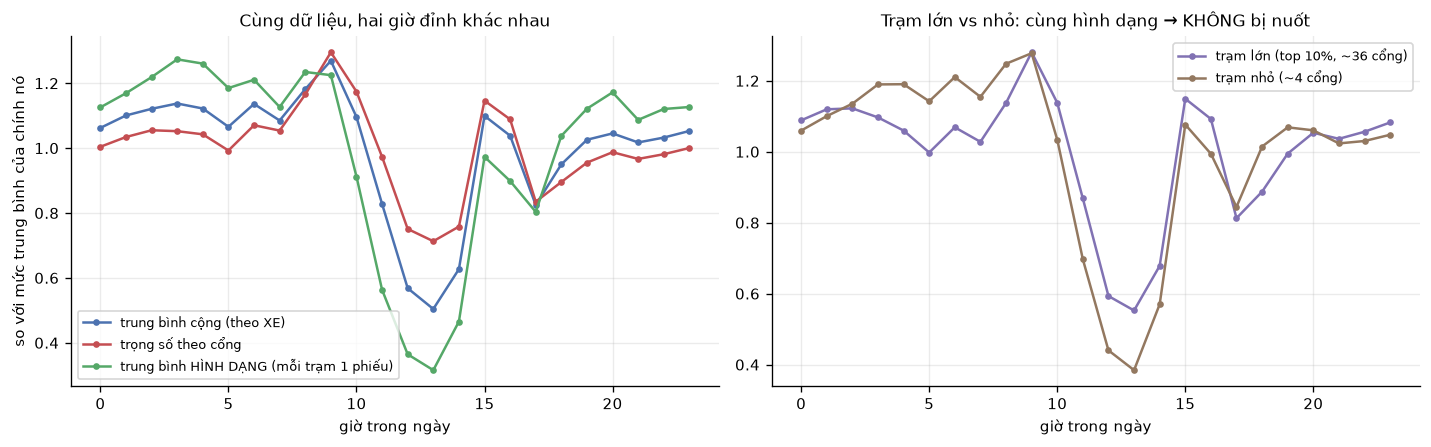

giờ đỉnh theo SỐ XE  : 9 h
giờ đỉnh theo HÌNH DẠNG mỗi trạm 1 phiếu: 3 h (gộp đỉnh) · 9 h (gộp trung bình)


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))

for col, lab, c in [("dinh_khong_trong_so", "trung bình cộng (theo XE)", "#4C72B0"),
                    ("dinh_trong_so_cong", "trọng số theo cổng", "#C44E52"),
                    ("trung_binh_hinh_dang", "trung bình HÌNH DẠNG (mỗi trạm 1 phiếu)", "#55A868")]:
    v = pd.Series(curves[col].to_numpy()).groupby(curves.hour).mean()
    ax[0].plot(v.index, v / v.mean(), marker="o", ms=3, label=lab, color=c)
ax[0].set_xlabel("giờ trong ngày"); ax[0].set_ylabel("so với mức trung bình của chính nó")
ax[0].legend(fontsize=8); ax[0].set_title("Cùng dữ liệu, hai giờ đỉnh khác nhau", fontsize=10)

for col, lab, c in [("chi_tram_lon", "trạm lớn (top 10%, ~36 cổng)", "#8172B3"),
                    ("chi_tram_nho", "trạm nhỏ (~4 cổng)", "#937860")]:
    v = pd.Series(curves[col].to_numpy()).groupby(curves.hour).mean()
    ax[1].plot(v.index, v / v.mean(), marker="o", ms=3, label=lab, color=c)
ax[1].set_xlabel("giờ trong ngày"); ax[1].legend(fontsize=8)
ax[1].set_title("Trạm lớn vs nhỏ: cùng hình dạng → KHÔNG bị nuốt", fontsize=10)
plt.tight_layout(); plt.show()

print("giờ đỉnh theo SỐ XE  :", A["5_tram_lon_nuot_duong_tong_hop"]["gio_dinh_trung_binh_khong_trong_so"], "h")
print("giờ đỉnh theo HÌNH DẠNG mỗi trạm 1 phiếu:", b["gio_dinh_hinh_dang__gop_MAX"], "h (gộp đỉnh) ·",
      b["gio_dinh_hinh_dang__gop_TRUNG_BINH"], "h (gộp trung bình)")

| Câu hỏi | Cách cân đúng | Đáp số |
|---|---|---|
| *"Lúc nào **nhiều xe nhất** đang sạc ở Hà Nội?"* | tổng số xe | **9h** |
| *"Trạm **điển hình** bận nhất lúc nào?"* | mỗi trạm một phiếu | **3h** *(gộp đỉnh)* / **9h** *(gộp trung bình)* |

Câu đầu dùng cho **vận hành lưới** (tổng tải). Câu sau dùng cho **quy hoạch** (một vị trí
mới thì kỳ vọng nhịp thế nào). Trộn hai câu là chỗ dễ sai nhất của cả lớp L8.

Chênh lệch 3h vs 9h ở cột "hình dạng" cũng nói lên một điều: rất nhiều trạm nhỏ có **đỉnh
ban đêm** — sạc qua đêm của đội xe. Gộp bằng đỉnh bắt được lần chạm cao nhất lúc rạng sáng;
gộp bằng trung bình lại thấy ban ngày bận đều hơn. **Cả hai đều thật.**

## 6.4 — Độ phân giải mịn mua được gì

Đây là cái bạn nghi "chưa tận dụng hết data": lưới **1 giờ** hiện tại nuốt mất các nhịp
ngắn hơn một giờ.

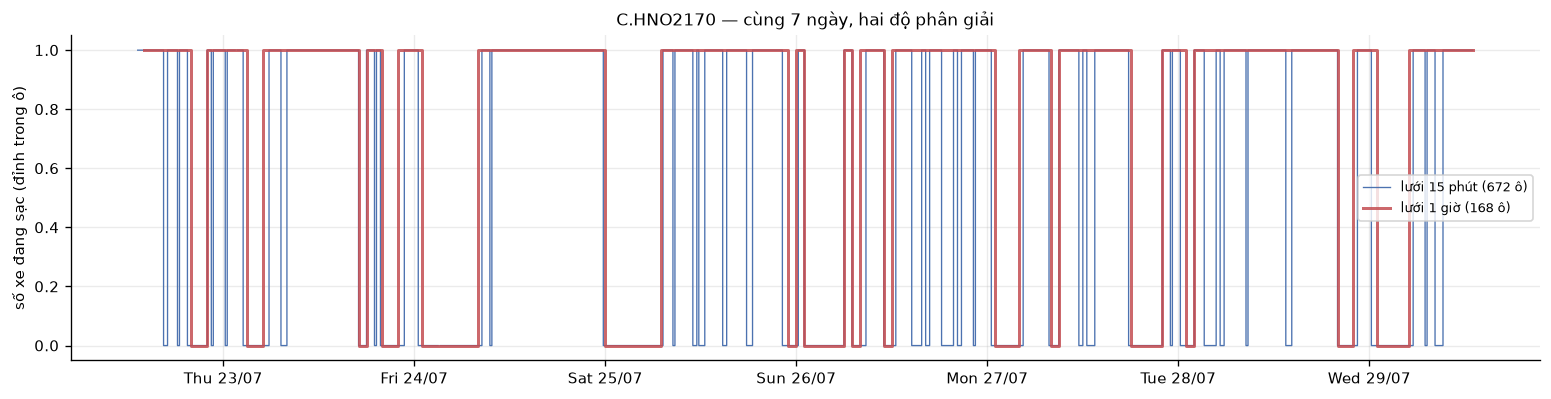

số lần đổi mức thấy được — 15 phút: 84 · 1 giờ: 32
biên độ (CV) — 15 phút: 0.843 · 1 giờ: 0.598


In [14]:
cov = np.isfinite(W15).sum(1)
pick = int(np.argsort(-cov)[3])
code = sidx[pick]
END15 = pd.Timestamp(A["1_nhip_lay_mau"]["ket_thuc_utc"]).tz_convert("Asia/Ho_Chi_Minh")

i15 = pd.date_range(end=END15, periods=672, freq="15min", tz="Asia/Ho_Chi_Minh")
i60 = pd.date_range(end=END15, periods=168, freq="1h", tz="Asia/Ho_Chi_Minh")

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.step(i15, W15[pick], where="post", lw=.8, color="#4C72B0", label="lưới 15 phút (672 ô)")
ax.step(i60, H[pick], where="post", lw=1.8, color="#C44E52", alpha=.85, label="lưới 1 giờ (168 ô)")
ax.set_ylabel("số xe đang sạc (đỉnh trong ô)")
ax.set_title(f"{code} — cùng 7 ngày, hai độ phân giải", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d/%m", tz=i15.tz))
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

d15 = np.abs(np.diff(W15[pick]))
d60 = np.abs(np.diff(H[pick]))
print(f"số lần đổi mức thấy được — 15 phút: {np.nansum(d15 > 0):.0f} · 1 giờ: {np.nansum(d60 > 0):.0f}")
print(f"biên độ (CV) — 15 phút: {np.nanstd(W15[pick])/np.nanmean(W15[pick]):.3f} · "
      f"1 giờ: {np.nanstd(H[pick])/np.nanmean(H[pick]):.3f}")

## 6.5 — Kết luận và việc phải sửa

**Ba nghi ngờ ban đầu của tôi đều bị bác bỏ bằng số đo.** Cách gộp không hỏng, múi giờ
không lệch, trạm lớn không nuốt. Metadata của nguồn khai báo trung thực mọi thứ.

**Cái hỏng là ở tầng hiển thị của tôi**, không phải tầng dữ liệu:

| Vấn đề | Sửa thế nào |
|---|---|
| Vẽ **một đường trung bình** cho 703 trạm lệch pha → mất 66,8% biên độ | Bỏ đường tổng hợp đơn lẻ. Thay bằng **dải phân vị** (p10–p50–p90) hoặc **nhóm nhịp** |
| Trộn hai câu hỏi "nhiều xe nhất" và "trạm điển hình" | Tách hẳn hai biểu đồ, ghi rõ cách cân ở tiêu đề |
| Lưới 1 giờ nuốt nhịp ngắn | Tuần **15′**, tháng **30′** — độ phủ trạm 83,8% / 93,8% |
| `d30` gộp ĐỈNH nhưng nhãn không nói | Ghi cách gộp **lên chính trục**, không để trong chú thích |

### Còn phải làm ở tầng pipeline

1. `s06_occupancy.py` xuất `station_timeline_hanoi.parquet` để bộ dữ liệu **đứng độc lập**
   (hiện biểu đồ 1 vẫn đọc repo nguồn).
2. Thêm cửa sổ **tuần 15′** và **tháng 30′**, mỗi cửa sổ kèm cột **độ phủ** — không có nó
   thì không phân biệt được "0 xe" với "không quan sát được".
3. Phát kèm **hình dạng đã chuẩn hoá** theo trạm, để tầng vẽ khỏi phải tự chuẩn hoá và
   khỏi tự ý chọn cách cân.